In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import os
from color_mapping import clean_color_column
from country_mapping import clean_country_column

file_path = os.path.expanduser("~/Desktop/regge.xlsx")
df = pd.read_excel(file_path)

official_apple_price = 949

model_discount = df[
    ["Preis", "Zustand", "Farbe", "Seller Rating", "Seller Type", "Herkunftsland"]
].copy()


def clean_price(x):
    if pd.isna(x):
        return np.nan
    x = (
        str(x)
        .replace("EUR", "")
        .replace("€", "")
        .replace(".", "")
        .replace(",", ".")
        .strip()
    )
    try:
        return float(x)
    except:
        return np.nan


def clean_rating(x):
    if pd.isna(x) or x == "N/A":
        return np.nan
    x = str(x).replace("%", "").replace(",", ".").strip()
    try:
        return float(x)
    except:
        return np.nan


model_discount["price"] = model_discount["Preis"].apply(clean_price)
model_discount["seller_rating"] = model_discount["Seller Rating"].apply(clean_rating)

model_discount["discount_eur"] = official_apple_price - model_discount["price"]
model_discount["discount_percent"] = (
    model_discount["discount_eur"] / official_apple_price
) * 100

model_discount["Zustand"] = (
    model_discount["Zustand"].astype(str).str.lower().str.strip()
)
model_discount["Farbe"] = model_discount["Farbe"].astype(str).str.lower().str.strip()

model_discount["Zustand"] = model_discount["Zustand"].replace(
    {"neu": "new", "gebraucht": "used", "refurbished": "refurbished"}
)

model_discount["Farbe"] = clean_color_column(model_discount["Farbe"])
model_discount["Herkunftsland"] = clean_country_column(model_discount["Herkunftsland"])


model_discount = model_discount.drop(columns=["Preis", "Seller Rating"])
model_discount = model_discount.dropna()

model_encoded = pd.get_dummies(
    model_discount,
    columns=["Zustand", "Farbe", "Seller Type", "Herkunftsland"],
    drop_first=True,
)

X = model_encoded.drop(["price", "discount_eur", "discount_percent"], axis=1)
y = model_encoded["discount_percent"]

X = X.astype(float)
y = y.astype(float)

X = sm.add_constant(X)

discount_model = sm.OLS(y, X).fit()

discount_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       discount_percent   R-squared:                       0.280
Model:                            OLS   Adj. R-squared:                  0.230
Method:                 Least Squares   F-statistic:                     5.518
Date:                Fri, 08 May 2026   Prob (F-statistic):           2.01e-08
Time:                        13:21:17   Log-Likelihood:                -692.97
No. Observations:                 198   AIC:                             1414.
Df Residuals:                     184   BIC:                             1460.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        13.9082      2.881      4.827      0.000       8.224      19.592
seller_rating                -0.0444      0.015     -3.011      0.003      -0.074      -0.015
Zustand_refurbished           0.7865      2.050      0.384      0.702      -3.257       4.830
Zustand_used                  8.3306      1.969      4.230      0.000       4.445      12.216
Farbe_blau - mist blue       14.9726      8.490      1.764      0.079      -1.777      31.723
Farbe_farbeinput            -24.7751      8.490     -2.918      0.004     -41.525      -8.026
Farbe_grün                   -1.0895      2.301     -0.474      0.636      -5.629       3.450
Farbe_lila                   -1.7961      2.184     -0.823      0.412      -6.104       2.512
Farbe_nebelgrau              -6.7695      8.606     -0.787      0.433     -23.749      10.210
Farbe_nicht verfügbar         2.7927      5.490      0.509      0.612      -8.039      13.624
Farbe_schwarz                 0.0592      1.777      0.033      0.973      -3.446       3.565
Farbe_weiß                   -3.3490      2.033     -1.648      0.101      -7.360       0.661
Seller Type_Privat            2.5883      1.516      1.707      0.089      -0.403       5.579
Herkunftsland_deutschland     0.8487      2.459      0.345      0.730      -4.003       5.701
==============================================================================
Omnibus:                       18.891   Durbin-Watson:                   1.659
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               22.927
Skew:                          -0.670   Prob(JB):                     1.05e-05
Kurtosis:                       3.992   Cond. No.                     1.04e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.04e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [2]:
best_deals = model_discount.sort_values("discount_percent", ascending=False)

best_deals[
    [
        "price",
        "discount_eur",
        "discount_percent",
        "Zustand",
        "Farbe",
        "Seller Type",
        "Herkunftsland",
    ]
].head(15)

,price,discount_eur,discount_percent,Zustand,Farbe,Seller Type,Herkunftsland
171,679.00,270.00,28.451001,used,weiß,Privat,deutschland
173,680.00,269.00,28.345627,used,schwarz,Privat,deutschland
189,680.00,269.00,28.345627,new,blau,Privat,deutschland
164,688.60,260.40,27.439410,new,nicht verfügbar,Gewerblich,ausland
12,699.90,249.10,26.248683,used,weiß,Gewerblich,deutschland
11,699.90,249.10,26.248683,used,schwarz,Gewerblich,deutschland
10,699.90,249.10,26.248683,used,blau,Gewerblich,deutschland
82,699.90,249.10,26.248683,new,weiß,Gewerblich,deutschland
90,699.90,249.10,26.248683,used,grün,Gewerblich,deutschland
194,699.99,249.01,26.239199,new,weiß,Privat,deutschland


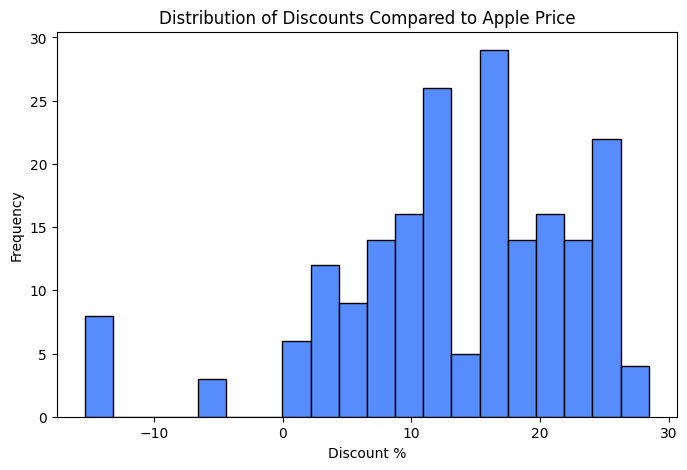

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(model_discount["discount_percent"], bins=20, edgecolor="black")
plt.xlabel("Discount %")
plt.ylabel("Frequency")
plt.title("Distribution of Discounts Compared to Apple Price")
plt.show()